# Study A — Kansas City Metropolitan Secondary Class Size Deep Dive
### School-by-School Comparisons, Course Granularity, and the Allocation Wedge Across 6 Federal Waves (2013–14 to 2023–24)
**Computational Sketchbook: Classroom Capacity and Class Size Research Design**  
*Data Sources: U.S. Department of Education Civil Rights Data Collection (CRDC 2013–14 through 2023–24 Waves) linked to NCES Common Core of Data (CCD).*

---

## 1. Research Question & Empirical Objectives

This notebook provides a dedicated empirical deep dive into the **Kansas City metropolitan area** across nine counties in Missouri and Kansas. We address four fundamental questions regarding secondary education capacity:

1. **Data Granularity & Epistemic Scope:** How granular is the federal Civil Rights Data Collection (CRDC), and what can (and cannot) be measured?
2. **School-Level Comparisons:** How do secondary class sizes vary across Kansas City high schools—comparing the urban core (KCPS), urban public charter schools, suburban Johnson County (KS), and suburban Northland / Jackson County (MO)?
3. **Class-Level Comparisons Within Schools (The Curriculum Hierarchy):** How do classes within the exact same school building vary across courses (e.g., Foundation Core vs. Advanced/AP offerings)?
4. **The Allocation Wedge:** Why do building-level Pupil/Teacher Ratios (typically 13:1 to 17:1) sharply diverge from real core classroom seat loads (frequently 24 to 31 students)?


In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Path configuration
NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
DATA_DIR = PROJECT_DIR / "data" / "processed"
CSV_PATH = DATA_DIR / "crdc_kc_metro_panel.csv"

# Styling configuration
sns.set_theme(style="whitegrid", font="sans-serif")
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "figure.titlesize": 14,
    "figure.dpi": 150,
})

# Custom palette
KC_PALETTE = {
    "Urban Core KCPS": "#D9381E",           # Amber-Red
    "Urban Charters": "#E67E22",            # Orange
    "Urban KCKPS": "#9B59B6",               # Purple
    "Suburban Johnson Co. (KS)": "#007A87", # Teal
    "Suburban Jackson Co. (MO)": "#002B49", # Navy
    "Suburban Northland (MO)": "#27AE60",   # Green
    "Outer Metropolitan": "#7F8C8D"         # Gray
}

print(f"Project directory: {PROJECT_DIR}")
print(f"Data file exists: {CSV_PATH.exists()}")


Project directory: C:\Users\admir\Github\computational-sketchbook\2026\2026-10-04-classroom-capacity
Data file exists: True


## 2. Epistemic Scope: What Can the CRDC Tell Us?

Before analyzing the numbers, it is essential to define the exact observational unit of the Civil Rights Data Collection:

| Dimension | CRDC Empirical Capability | Interpretation & Limitation |
| :--- | :---: | :--- |
| **Observational Unit** | **School Building $\times$ Course Offering** | Reports data for each reporting school building for 8 monitored secondary STEM courses. |
| **Reported Metrics** | **Sections ($K$) & Enrollment ($E$)** | Explicit counts of total class sections offered and total students enrolled in each course. |
| **Derived Class Size** | **School-Course Mean ($\bar C = E / K$)** | The exact average section size for that course offering within that school. |
| **Demographic Disaggregation** | **Yes (Race, Sex, IDEA, EL)** | Course-level enrollment disaggregated by student demographics. |
| **Teacher Certification** | **Yes ($K_{\text{cert}}$)** | Number of sections taught by certified teachers in that subject. |
| **Period-by-Period Microdata** | **No** | CRDC does **not** provide period-by-period schedules (e.g. Period 2 vs Period 4) or individual teacher rosters. |
| **Teacher Identity Linkage** | **No** | Teacher names/IDs are not attached to sections in public-use CRDC files. |

> **Key Takeaway on Granularity:**  
> We **can** directly compare schools to schools on identical courses (e.g., Geometry at Lincoln College Prep vs. Geometry at Blue Valley High).  
> We **can** compare courses within schools to examine tracking and resource allocation (e.g., Algebra I vs. Calculus).  
> We **cannot** observe within-cell section variance (e.g., whether one Algebra section has 32 students and another has 20). Mathematically, by Jensen's inequality, the enrollment-weighted school-course mean is a rigorous **lower-bound proxy** for true student-experienced section size.


In [2]:
# 1. Load data
df = pd.read_csv(CSV_PATH, low_memory=False)

# 2. Filter to valid class sizes (exclude reporting anomalies/data entry errors > 60)
df_clean = df[(df["mean_class_size"] > 0) & (df["mean_class_size"] <= 60)].copy()

# 3. Standardize Sector Classification
def classify_sector(row):
    dist = str(row["district_name"]).strip().upper()
    sch = str(row["school_name"]).strip().upper()
    state = str(row["state"]).strip().upper()
    county = str(row["county_name"]).strip()
    
    # Charters
    charter_keywords = ["ACADEMY", "CHARTER", "KAUFFMAN", "LAFAYETTE", "FRONTIER", "GUADALUPE", "CROSSROADS", "VILLAGE", "DE LA SALLE", "DELASALLE"]
    if any(k in dist for k in charter_keywords) or any(k in sch for k in ["UNIVERSITY ACADEMY", "KAUFFMAN", "HOGAN PREP", "ACADEMIE LAFAYETTE"]):
        return "Urban Charters"
    
    # KCPS (MO Urban Core)
    if "KANSAS CITY 33" in dist or dist == "KANSAS CITY" and state == "MO":
        return "Urban Core KCPS"
    
    # KCKPS (KS Urban Core)
    if ("KANSAS CITY" in dist or "USD 500" in dist) and state == "KS":
        return "Urban KCKPS"
    
    # Suburban Johnson County KS
    if any(d in dist for d in ["BLUE VALLEY", "SHAWNEE MISSION", "OLATHE", "DE SOTO", "GARDNER EDGERTON", "SPRING HILL"]) or "Johnson" in county:
        return "Suburban Johnson Co. (KS)"
    
    # Suburban Northland MO (Clay & Platte)
    if any(d in dist for d in ["NORTH KANSAS CITY", "PARK HILL", "LIBERTY", "PLATTE COUNTY", "SMITHVILLE"]) or "Clay" in county or "Platte" in county:
        return "Suburban Northland (MO)"
    
    # Suburban Jackson County MO
    if any(d in dist for d in ["LEE'S SUMMIT", "BLUE SPRINGS", "INDEPENDENCE", "RAYTOWN", "CENTER", "GRANDVIEW", "HICKMAN MILLS", "FORT OSAGE", "GRAIN VALLEY"]) or "Jackson" in county:
        return "Suburban Jackson Co. (MO)"
    
    return "Outer Metropolitan"

df_clean["sector"] = df_clean.apply(classify_sector, axis=1)

print(f"Total Raw Records: {len(df):,}")
print(f"Valid Analytical Records: {len(df_clean):,}")
print(f"Unique Schools: {df_clean['nces_school_id'].nunique():,}")
print(f"Waves Covered: {sorted(df_clean['crdc_wave'].unique())}")
print("\nObservations by Sector:")
print(df_clean['sector'].value_counts())


Total Raw Records: 4,545
Valid Analytical Records: 4,502
Unique Schools: 171
Waves Covered: ['2013-14', '2015-16', '2017-18', '2020-21', '2021-22', '2023-24']

Observations by Sector:
sector
Suburban Johnson Co. (KS)    944
Outer Metropolitan           942
Suburban Jackson Co. (MO)    932
Suburban Northland (MO)      747
Urban KCKPS                  342
Urban Charters               304
Urban Core KCPS              291
Name: count, dtype: int64


## 3. Sector-Level Overview: Class Size Across the Metropolitan Landscape

In the latest 2023–24 federal wave, how do class sizes and campus staffing ratios vary across Kansas City sectors?
We evaluate three key estimands:
- **Unweighted Mean ($\bar C_{\text{cell}}$):** Average across school-course offerings.
- **Section-Weighted Mean ($\bar C_{\text{sec}}$):** Total students divided by total sections across schools in that sector.
- **Student / Seat-Weighted Mean ($\bar C_{\text{seat}}$):** The average section size experienced by an enrolled student.
- **Campus PTR:** The building-level pupil/teacher ratio.
- **Allocation Wedge:** The gap between seat-weighted class size and campus PTR.


,Sector,Schools,Courses Offered,Total Classes,Total Enrolled,Unweighted Mean,Section-Weighted Mean,Seat-Weighted Mean,Campus PTR,Allocation Wedge
2,Suburban Johnson Co. (KS),21,159,2027,42226,21.09,20.83,21.75,15.99,5.76
5,Urban Core KCPS,7,49,344,6573,17.36,19.11,21.07,12.91,8.16
3,Suburban Northland (MO),19,127,1289,24387,17.36,18.92,19.93,14.93,5.00
4,Urban Charters,12,71,290,4650,16.87,16.03,19.39,11.44,7.95
1,Suburban Jackson Co. (MO),26,151,2216,33289,14.50,15.02,19.11,14.98,4.13
6,Urban KCKPS,10,61,804,12563,14.75,15.63,18.90,15.72,3.19
0,Outer Metropolitan,26,157,961,13687,13.32,14.24,17.91,14.17,3.74


C:\Users\admir\AppData\Local\Temp\ipykernel_22660\1039368599.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


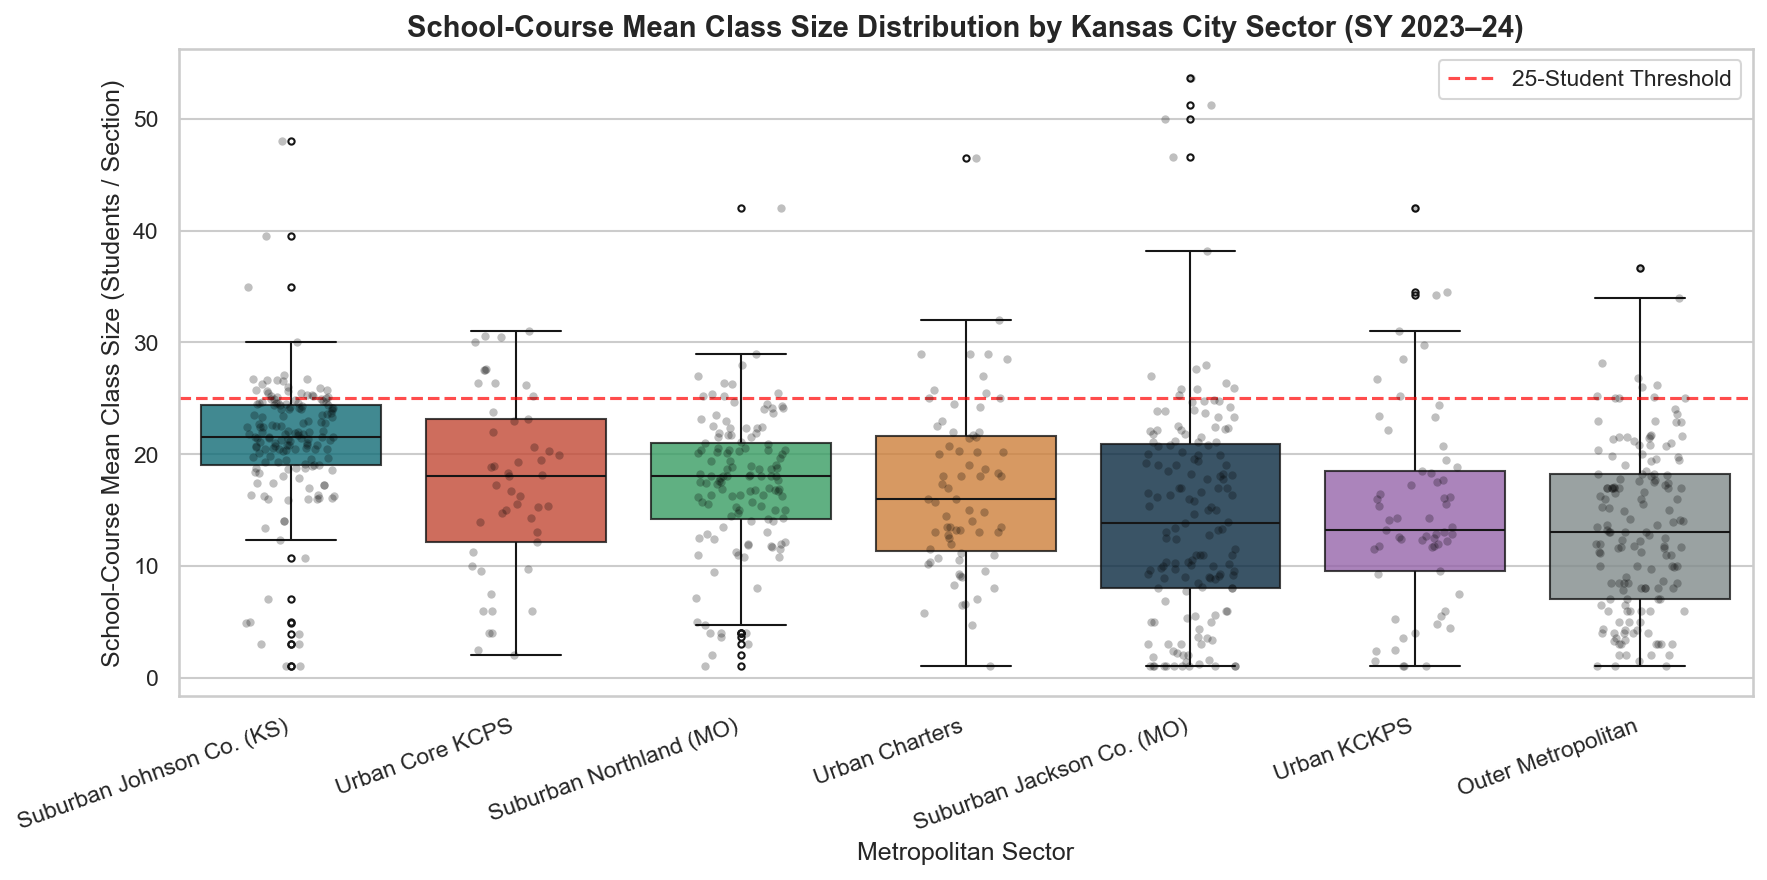

In [3]:
df_23 = df_clean[df_clean["crdc_wave"] == "2023-24"].copy()

sector_summary = []
for sector, grp in df_23.groupby("sector"):
    k_tot = grp["num_classes"].sum()
    e_tot = grp["num_enrolled"].sum()
    
    sec_wt_mean = e_tot / k_tot if k_tot > 0 else np.nan
    seat_wt_mean = (grp["mean_class_size"] * grp["num_enrolled"]).sum() / e_tot if e_tot > 0 else np.nan
    cell_mean = grp["mean_class_size"].mean()
    ptr_mean = grp["school_ptr"].mean()
    wedge = seat_wt_mean - ptr_mean
    
    sector_summary.append({
        "Sector": sector,
        "Schools": grp["nces_school_id"].nunique(),
        "Courses Offered": len(grp),
        "Total Classes": int(k_tot),
        "Total Enrolled": int(e_tot),
        "Unweighted Mean": round(cell_mean, 2),
        "Section-Weighted Mean": round(sec_wt_mean, 2),
        "Seat-Weighted Mean": round(seat_wt_mean, 2),
        "Campus PTR": round(ptr_mean, 2),
        "Allocation Wedge": round(wedge, 2)
    })

df_sec_summary = pd.DataFrame(sector_summary).sort_values("Seat-Weighted Mean", ascending=False)
display(df_sec_summary)

# Distribution plot
plt.figure(figsize=(12, 6))
order = df_sec_summary["Sector"].tolist()
sns.boxplot(
    data=df_23,
    x="sector",
    y="mean_class_size",
    order=order,
    palette=KC_PALETTE,
    fliersize=3,
    boxprops=dict(alpha=0.8)
)
sns.stripplot(
    data=df_23,
    x="sector",
    y="mean_class_size",
    order=order,
    color="black",
    alpha=0.25,
    jitter=0.2,
    size=4
)
plt.title("School-Course Mean Class Size Distribution by Kansas City Sector (SY 2023–24)", fontsize=14, fontweight="bold")
plt.xlabel("Metropolitan Sector")
plt.ylabel("School-Course Mean Class Size (Students / Section)")
plt.xticks(rotation=20, ha="right")
plt.axhline(25, color="red", linestyle="--", alpha=0.7, label="25-Student Threshold")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


## 4. School-Level Comparisons: How Do Kansas City High Schools Compare?

Here we directly compare major comprehensive high schools across the metropolitan area for the 2023–24 school year.
We examine:
- **KCPS Urban Comprehensive & Magnet High Schools:** Lincoln College Prep, Central High, East High, Northeast High, Paseo Academy, Southeast High.
- **Urban Charter High Schools:** University Academy, Hogan Prep, Ewing Marion Kauffman, Academie Lafayette.
- **Suburban Johnson County (KS) High Schools:** Blue Valley High, Blue Valley North, Blue Valley Northwest, Blue Valley West, Shawnee Mission East, Shawnee Mission North, Olathe Northwest.
- **Suburban Northland & Jackson County (MO) High Schools:** North Kansas City High, Oak Park High, Staley High, Lee's Summit West, Blue Springs High, Liberty High.


course_name,sector,display_name,school_ptr,Algebra I,Geometry,Algebra II,Biology,Chemistry,Physics,Calculus,Advanced Mathematics
1,Suburban Jackson Co. (MO),Lee'S Summit West High,16.3,16.6,24.8,20.7,13.8,16.3,12.4,—,13.2
0,Suburban Jackson Co. (MO),Blue Springs High,16.1,20.8,22.2,20.0,16.4,19.9,17.8,20.8,22.5
6,Suburban Johnson Co. (KS),Olathe Northwest High,16.6,26.6,27.1,21.7,20.4,22.8,20.4,26.7,24.6
9,Suburban Johnson Co. (KS),Shawnee Mission Northwest High,16.6,25.7,25.9,24.9,22.0,21.4,21.5,21.0,24.1
8,Suburban Johnson Co. (KS),Shawnee Mission North High,14.2,25.7,24.8,24.6,20.8,21.8,21.5,16.0,25.0
4,Suburban Johnson Co. (KS),Blue Valley Northwest High,15.7,22.4,24.4,24.1,17.8,26.8,24.7,18.6,18.1
7,Suburban Johnson Co. (KS),Shawnee Mission East High,17.5,25.3,24.3,25.2,21.9,22.0,22.7,24.6,24.8
5,Suburban Johnson Co. (KS),Blue Valley West High,15.6,24.0,24.1,22.1,19.8,23.7,25.5,17.3,20.7
2,Suburban Johnson Co. (KS),Blue Valley High,15.8,21.5,23.3,24.1,17.4,20.5,19.6,16.4,16.2
3,Suburban Johnson Co. (KS),Blue Valley North High,15.9,35.0,22.5,18.4,17.4,20.5,23.4,15.9,16.1


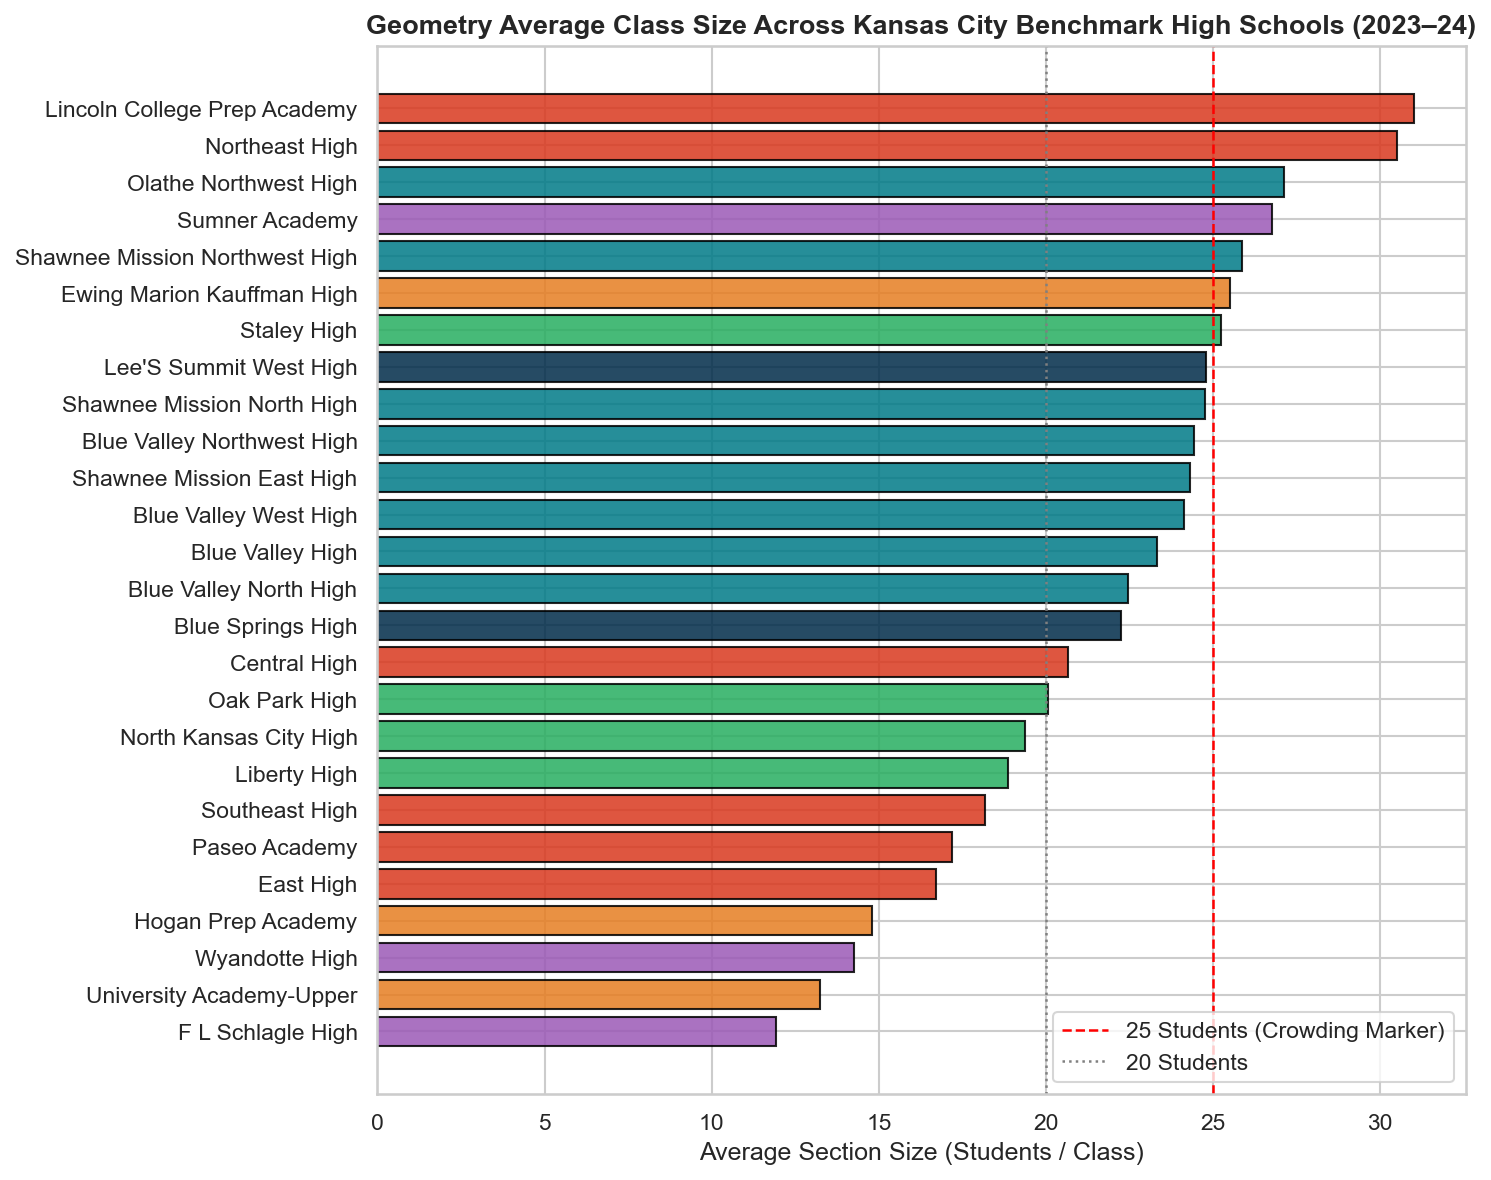

In [4]:
# Select benchmark schools
benchmark_keywords = [
    "LINCOLN COLLEGE PREPARATORY", "CENTRAL HIGH SCHOOL", "EAST HIGH SCHOOL", "NORTHEAST HIGH",
    "PASEO ACADEMY", "SOUTHEAST HIGH", "SUMNER ACADEMY", "WYANDOTTE HIGH", "F L SCHLAGLE",
    "BLUE VALLEY HIGH", "BLUE VALLEY NORTH HIGH", "BLUE VALLEY NORTHWEST", "BLUE VALLEY WEST",
    "SHAWNEE MISSION EAST", "SHAWNEE MISSION NORTH", "OLATHE NORTHWEST", "NORTH KANSAS CITY HIGH",
    "OAK PARK HIGH", "STALEY HIGH", "LEE'S SUMMIT WEST", "BLUE SPRINGS HIGH", "LIBERTY HIGH",
    "UNIVERSITY ACADEMY", "EWING MARION KAUFFMAN", "HOGAN PREPARATORY"
]

bench_df = df_23[df_23["school_name"].str.upper().apply(lambda s: any(k in s for k in benchmark_keywords))].copy()

# Clean school names for clean presentation
def shorten_name(name):
    name = name.title()
    replacements = {
        "High School": "High",
        "Preparatory": "Prep",
        "Academy Of Fine & Performing Arts": "Academy",
        "Of Arts & Science": "",
        "College Preparatory Academy": "College Prep",
        "College Prep.": "College Prep"
    }
    for old, new in replacements.items():
        name = name.replace(old, new)
    return name.strip()

bench_df["display_name"] = bench_df["school_name"].apply(shorten_name)

# Pivot to school x course
course_order = ["Algebra I", "Geometry", "Algebra II", "Biology", "Chemistry", "Physics", "Calculus", "Advanced Mathematics"]
bench_pivot = bench_df.pivot_table(
    index=["sector", "display_name", "school_ptr"],
    columns="course_name",
    values="mean_class_size",
    aggfunc="mean"
)[course_order]

bench_pivot = bench_pivot.reset_index().sort_values(["sector", "Geometry"], ascending=[True, False])
display(bench_pivot.style.format(precision=1, na_rep="—").background_gradient(cmap="YlOrRd", subset=course_order, vmin=10, vmax=32))

# Plot top schools on Core Geometry
plt.figure(figsize=(10, 8))
geom_df = bench_df[bench_df["course_name"] == "Geometry"].sort_values("mean_class_size", ascending=True)

colors = [KC_PALETTE.get(s, "#333") for s in geom_df["sector"]]
bars = plt.barh(geom_df["display_name"], geom_df["mean_class_size"], color=colors, edgecolor="black", alpha=0.85)

plt.axvline(25, color="red", linestyle="--", linewidth=1.2, label="25 Students (Crowding Marker)")
plt.axvline(20, color="gray", linestyle=":", linewidth=1.2, label="20 Students")

plt.title("Geometry Average Class Size Across Kansas City Benchmark High Schools (2023–24)", fontsize=13, fontweight="bold")
plt.xlabel("Average Section Size (Students / Class)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 5. Course-Level Comparisons Within Schools: The Curriculum Hierarchy

A central empirical question in classroom capacity research is:
> **Do schools maintain uniform class sizes across the curriculum, or do advanced and elective offerings siphon off instructional FTEs, driving up class sizes in foundation core subjects?**

By comparing Foundation Core courses (**Algebra I, Geometry, Algebra II, Biology, Chemistry**) directly against Advanced / Specialized courses (**Calculus, Physics, Advanced Mathematics**) within the exact same schools, we observe the **Curriculum Hierarchy**.


Top 10 High Schools with the Largest Core vs. Advanced Class Size Gap:


course_type                                                          Advanced STEM  \
sector                    school_name                                                
Suburban Johnson Co. (KS) INSIGHT SCHOOL OF KS AT HILLTOP ED CENTER           4.00   
Suburban Jackson Co. (MO) FORT OSAGE HIGH                                    21.83   
                          RUSKIN HIGH SCHOOL                                  5.50   
Outer Metropolitan        HARDIN-CENTRAL HIGH                                 3.00   
Suburban Jackson Co. (MO) GRANDVIEW SR. HIGH                                  9.25   
                          OAK GROVE HIGH                                      2.50   
Urban Charters            FRONTIER STEM HIGH SCHOOL                           7.58   
Urban Core KCPS           LINCOLN COLLEGE PREPARATORY ACADEMY                14.87   
Urban Charters            KIPP KC LEGACY HIGH SCHOOL                         15.40   
Suburban Northland (MO)   OAK PARK HIGH                                       8.74   

course_type                                                          Foundation Core  \
sector                    school_name                                                  
Suburban Johnson Co. (KS) INSIGHT SCHOOL OF KS AT HILLTOP ED CENTER            39.17   
Suburban Jackson Co. (MO) FORT OSAGE HIGH                                      43.11   
                          RUSKIN HIGH SCHOOL                                   26.23   
Outer Metropolitan        HARDIN-CENTRAL HIGH                                  17.67   
Suburban Jackson Co. (MO) GRANDVIEW SR. HIGH                                   23.14   
                          OAK GROVE HIGH                                       15.65   
Urban Charters            FRONTIER STEM HIGH SCHOOL                            20.56   
Urban Core KCPS           LINCOLN COLLEGE PREPARATORY ACADEMY                  27.60   
Urban Charters            KIPP KC LEGACY HIGH SCHOOL                           27.58   
Suburban Northland (MO)   OAK PARK HIGH                                        20.35   

course_type                                                          Difference (Core - Adv)  
sector                    school_name                                                         
Suburban Johnson Co. (KS) INSIGHT SCHOOL OF KS AT HILLTOP ED CENTER                    35.17  
Suburban Jackson Co. (MO) FORT OSAGE HIGH                                              21.28  
                          RUSKIN HIGH SCHOOL                                           20.73  
Outer Metropolitan        HARDIN-CENTRAL HIGH                                          14.67  
Suburban Jackson Co. (MO) GRANDVIEW SR. HIGH                                           13.89  
                          OAK GROVE HIGH                                               13.15  
Urban Charters            FRONTIER STEM HIGH SCHOOL                                    12.97  
Urban Core KCPS           LINCOLN COLLEGE PREPARATORY ACADEMY                          12.74  
Urban Charters            KIPP KC LEGACY HIGH SCHOOL                                   12.18  
Suburban Northland (MO)   OAK PARK HIGH                                                11.61

C:\Users\admir\AppData\Local\Temp\ipykernel_22660\3130892266.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


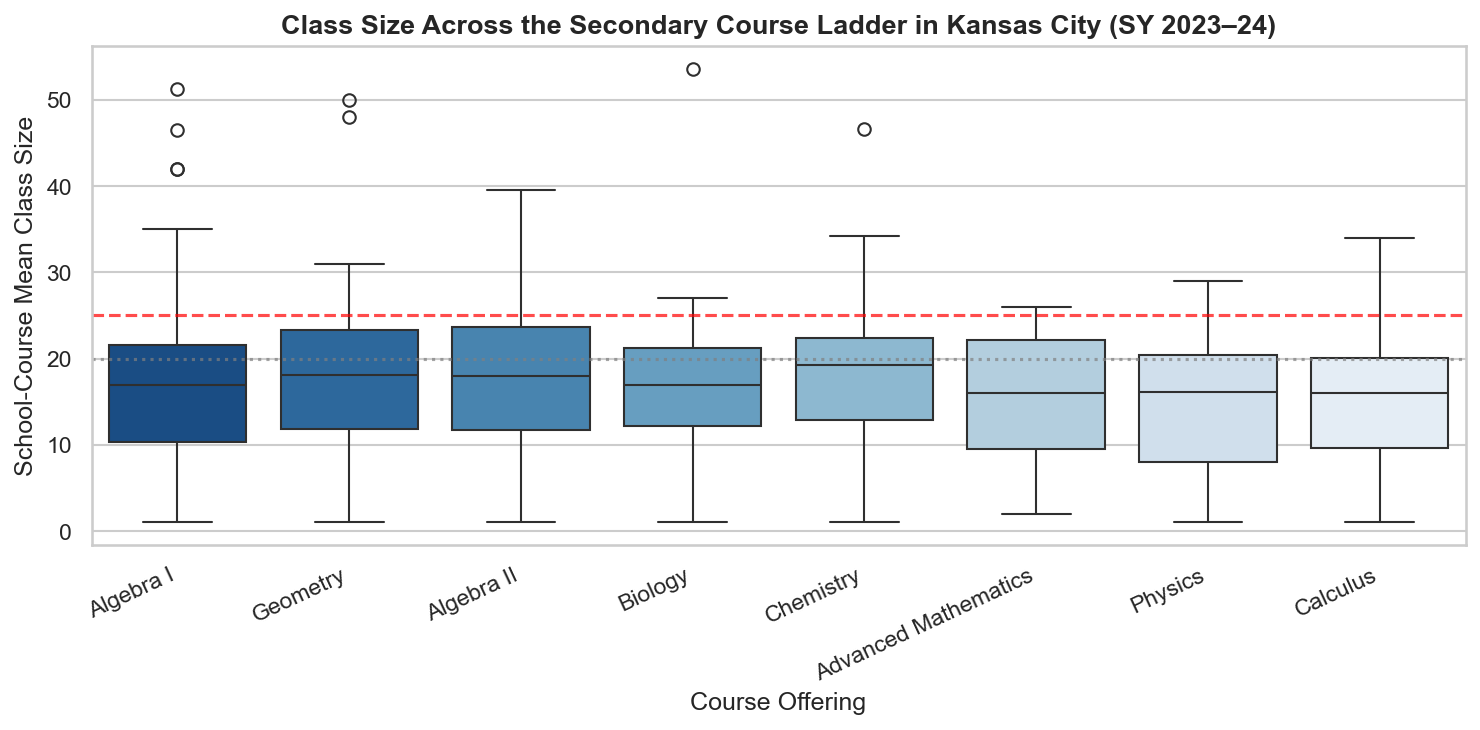

In [5]:
# Compare Foundation Core vs Advanced STEM
df_23["course_type"] = df_23["course_level"].map({
    "Foundation Core": "Foundation Core",
    "Advanced / Specialized": "Advanced STEM"
}).fillna(df_23["course_name"].apply(lambda c: "Advanced STEM" if c in ["Calculus", "Physics", "Advanced Mathematics"] else "Foundation Core"))

school_hierarchy = df_23.groupby(["sector", "school_name", "course_type"])["mean_class_size"].mean().unstack().dropna()
school_hierarchy["Difference (Core - Adv)"] = school_hierarchy["Foundation Core"] - school_hierarchy["Advanced STEM"]
school_hierarchy = school_hierarchy.sort_values("Difference (Core - Adv)", ascending=False)

print("Top 10 High Schools with the Largest Core vs. Advanced Class Size Gap:")
display(school_hierarchy.head(10).round(2))

# Paired Boxplot
plt.figure(figsize=(10, 5))
paired_df = df_23[df_23["course_type"].isin(["Foundation Core", "Advanced STEM"])].copy()

sns.boxplot(
    data=paired_df,
    x="course_name",
    y="mean_class_size",
    order=["Algebra I", "Geometry", "Algebra II", "Biology", "Chemistry", "Advanced Mathematics", "Physics", "Calculus"],
    palette="Blues_r"
)
plt.title("Class Size Across the Secondary Course Ladder in Kansas City (SY 2023–24)", fontsize=13, fontweight="bold")
plt.xlabel("Course Offering")
plt.ylabel("School-Course Mean Class Size")
plt.xticks(rotation=25, ha="right")
plt.axhline(20, color="gray", linestyle=":", alpha=0.7)
plt.axhline(25, color="red", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


## 6. The Allocation Wedge: Why Building PTR Masks Classroom Realities

School-level Pupil/Teacher Ratios (PTR) are frequently cited in public policy debates as proxies for class size. However:
1. PTR includes instructional coaches, department heads, media specialists, and specialty teachers who do not teach full core loads.
2. Secondary teachers instruct 4–5 periods out of a 6–7 period schedule, reserving prep periods.
3. Advanced and specialized courses enroll small sections (e.g. 5–12 students), pulling down the campus average.

The **Allocation Wedge** is defined as:
$$\text{Wedge}_{s,c} = \text{Mean Class Size}_{s,c} - \text{Campus PTR}_s$$
A positive wedge indicates that actual academic class sizes are larger than the building PTR implies.


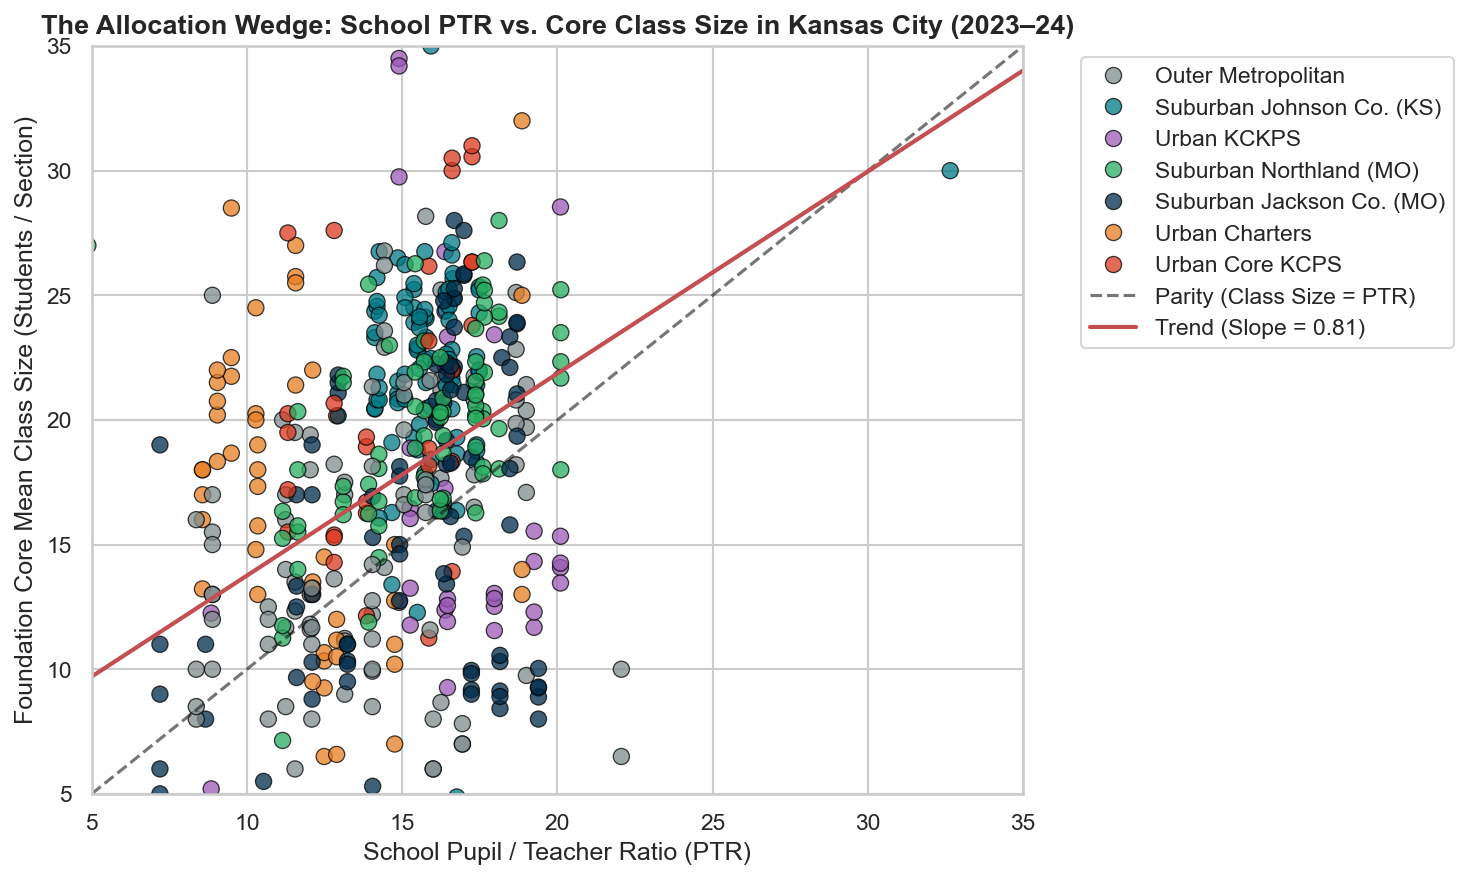

Top 15 Kansas City High Schools with the Largest Allocation Wedge:


,sector,school_name,school_ptr,mean_class_size,Average Core Wedge
32,Suburban Jackson Co. (MO),FORT OSAGE HIGH,18.21,43.11,24.90
89,Suburban Northland (MO),WATKINS MILL PARK CAMP,4.88,24.33,19.45
101,Urban Charters,KIPP KC LEGACY HIGH SCHOOL,9.50,27.58,18.08
114,Urban KCKPS,PIPER HIGH,14.90,30.63,15.73
97,Urban Charters,EWING MARION KAUFFMAN HIGH,11.57,24.91,13.34
47,Suburban Jackson Co. (MO),RUSKIN HIGH SCHOOL,12.94,26.23,13.29
99,Urban Charters,FRONTIER STEM HIGH SCHOOL,9.05,20.56,11.51
105,Urban Core KCPS,LINCOLN COLLEGE PREPARATORY ACADEMY,17.25,27.60,10.35
100,Urban Charters,HOGAN PREPARATORY ACADEMY,10.29,19.89,9.60
68,Suburban Johnson Co. (KS),SHAWNEE MISSION NORTH HIGH,14.19,23.53,9.34


In [6]:
# Scatter plot: PTR vs Foundation Core Class Size
core_23 = df_23[df_23["course_type"] == "Foundation Core"].dropna(subset=["school_ptr", "mean_class_size"]).copy()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=core_23,
    x="school_ptr",
    y="mean_class_size",
    hue="sector",
    palette=KC_PALETTE,
    alpha=0.75,
    s=60,
    edgecolor="black"
)

# 45-degree line
lims = [5, 35]
plt.plot(lims, lims, "k--", alpha=0.6, label="Parity (Class Size = PTR)")

# Fit line
z = np.polyfit(core_23["school_ptr"], core_23["mean_class_size"], 1)
p = np.poly1d(z)
plt.plot(np.array(lims), p(np.array(lims)), "r-", linewidth=2, label=f"Trend (Slope = {z[0]:.2f})")

plt.title("The Allocation Wedge: School PTR vs. Core Class Size in Kansas City (2023–24)", fontsize=13, fontweight="bold")
plt.xlabel("School Pupil / Teacher Ratio (PTR)")
plt.ylabel("Foundation Core Mean Class Size (Students / Section)")
plt.xlim(lims)
plt.ylim(lims)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Schools with highest allocation wedge in 2023-24
top_wedges = core_23.groupby(["sector", "school_name", "school_ptr"])["mean_class_size"].mean().reset_index()
top_wedges["Average Core Wedge"] = top_wedges["mean_class_size"] - top_wedges["school_ptr"]
top_wedges = top_wedges.sort_values("Average Core Wedge", ascending=False)

print("Top 15 Kansas City High Schools with the Largest Allocation Wedge:")
display(top_wedges.head(15).round(2))


## 7. Upper-Tail Concentration: Where Are Crowded Classrooms Concentrated?

Headline averages often obscure the distribution of crowded classes. In many districts, a building mean of 20 students coexists with severe crowding in general education core sections.

Here we measure the proportion of course offerings and enrolled seats operating at:
- **$\ge 25$ Students per Class** (Standard crowding marker)
- **$\ge 30$ Students per Class** (Severe crowding marker)


,Sector,Total Offerings,Total Seats,% Offerings >= 25,% Seats >= 25,% Offerings >= 30,% Seats >= 30
5,Urban Core KCPS,49,6573,22.4,31.3,8.2,13.5
6,Urban KCKPS,61,12563,13.1,23.8,6.6,5.5
4,Urban Charters,71,4650,15.5,20.2,2.8,5.4
2,Suburban Johnson Co. (KS),159,42226,16.4,15.8,2.5,0.9
0,Outer Metropolitan,157,13687,7.0,14.9,1.3,2.9
1,Suburban Jackson Co. (MO),151,33289,8.6,13.6,3.3,5.1
3,Suburban Northland (MO),127,24387,7.9,10.8,0.8,0.2


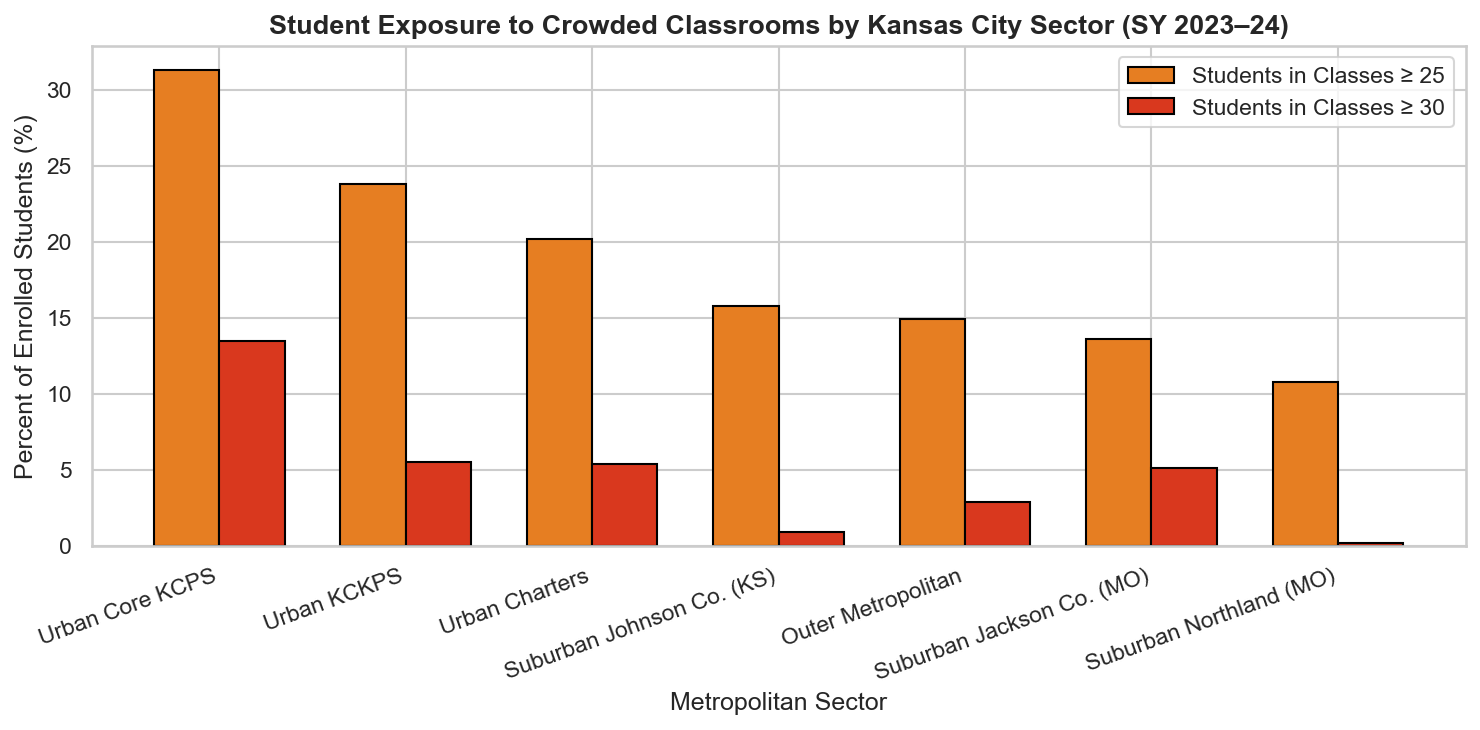

In [7]:
tail_records = []
for sector, grp in df_23.groupby("sector"):
    tot_offerings = len(grp)
    tot_seats = grp["num_enrolled"].sum()
    
    ge25_offerings = (grp["mean_class_size"] >= 25).sum()
    ge30_offerings = (grp["mean_class_size"] >= 30).sum()
    
    ge25_seats = grp.loc[grp["mean_class_size"] >= 25, "num_enrolled"].sum()
    ge30_seats = grp.loc[grp["mean_class_size"] >= 30, "num_enrolled"].sum()
    
    tail_records.append({
        "Sector": sector,
        "Total Offerings": tot_offerings,
        "Total Seats": int(tot_seats),
        "% Offerings >= 25": round(100 * ge25_offerings / tot_offerings, 1),
        "% Seats >= 25": round(100 * ge25_seats / tot_seats, 1),
        "% Offerings >= 30": round(100 * ge30_offerings / tot_offerings, 1),
        "% Seats >= 30": round(100 * ge30_seats / tot_seats, 1)
    })

df_tail = pd.DataFrame(tail_records).sort_values("% Seats >= 25", ascending=False)
display(df_tail)

# Bar chart of seat exposure
plt.figure(figsize=(10, 5))
x = np.arange(len(df_tail))
width = 0.35

plt.bar(x - width/2, df_tail["% Seats >= 25"], width, label="Students in Classes ≥ 25", color="#E67E22", edgecolor="black")
plt.bar(x + width/2, df_tail["% Seats >= 30"], width, label="Students in Classes ≥ 30", color="#D9381E", edgecolor="black")

plt.title("Student Exposure to Crowded Classrooms by Kansas City Sector (SY 2023–24)", fontsize=13, fontweight="bold")
plt.xlabel("Metropolitan Sector")
plt.ylabel("Percent of Enrolled Students (%)")
plt.xticks(x, df_tail["Sector"], rotation=20, ha="right")
plt.legend()
plt.tight_layout()
plt.show()


## 8. Longitudinal Trajectory Across 6 Federal Waves (2013–14 to 2023–24)

How have secondary class sizes changed over the past decade in Kansas City?
We examine whether class sizes compressed during the COVID-19 pandemic wave (2020–21) and whether they rebounded in subsequent waves (2021–22 and 2023–24).


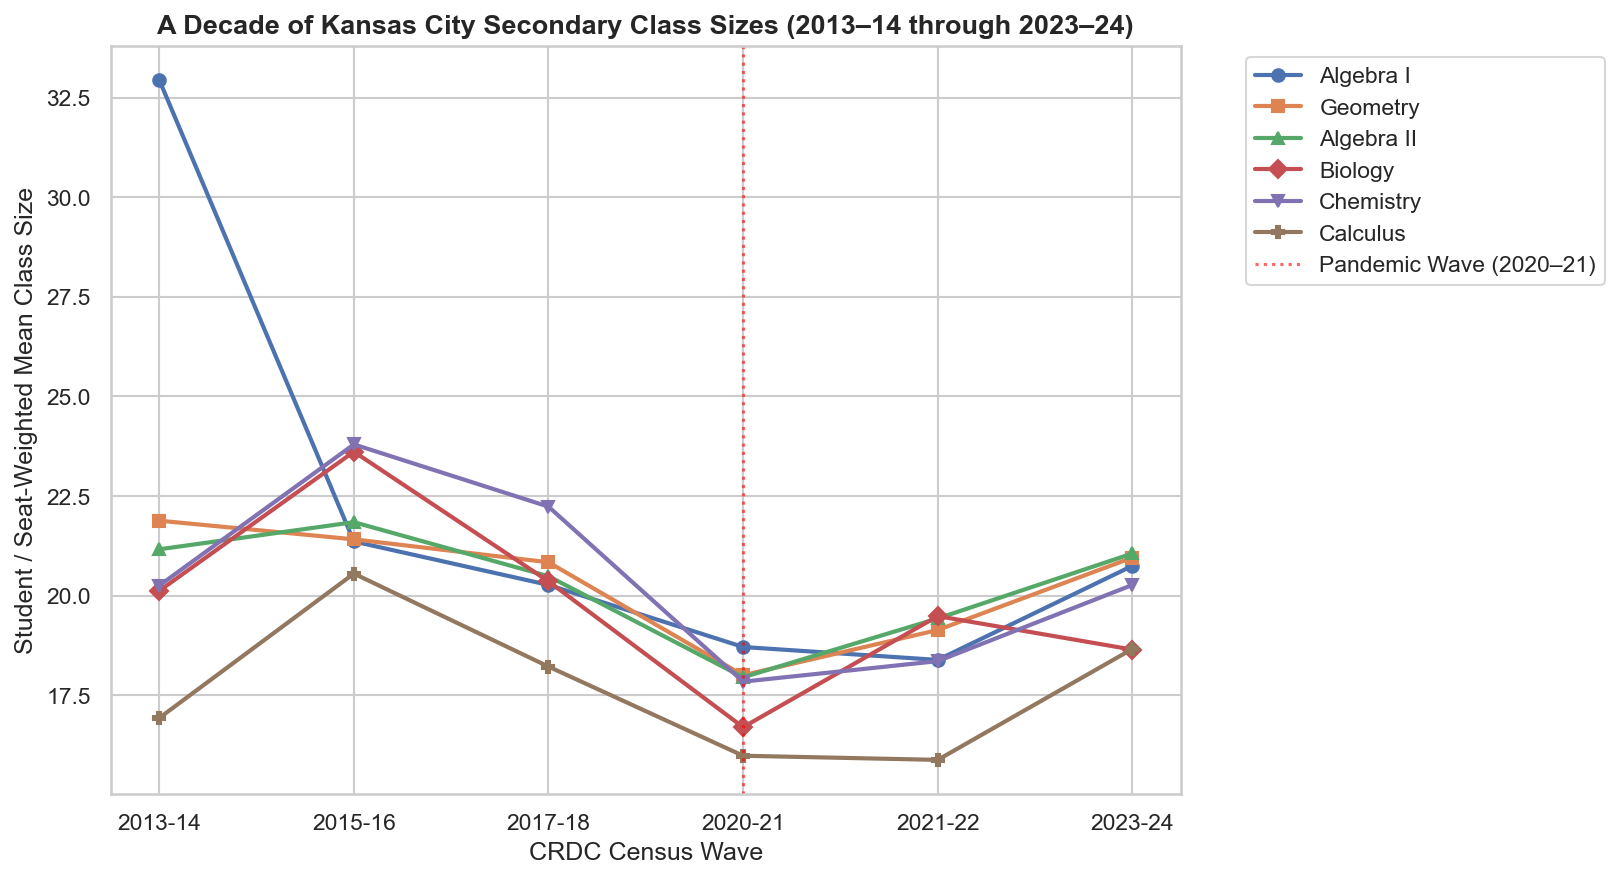

In [8]:
# Compute longitudinal seat-weighted means by course and wave
long_summary = []
for (wave, course), grp in df_clean.groupby(["crdc_wave", "course_name"]):
    tot_e = grp["num_enrolled"].sum()
    tot_k = grp["num_classes"].sum()
    if tot_e > 0 and tot_k > 0:
        seat_mean = (grp["mean_class_size"] * grp["num_enrolled"]).sum() / tot_e
        sec_mean = tot_e / tot_k
        long_summary.append({
            "CRDC Wave": wave,
            "Course Name": course,
            "Section-Weighted Mean": sec_mean,
            "Seat-Weighted Mean": seat_mean
        })

df_long = pd.DataFrame(long_summary)

plt.figure(figsize=(11, 6))
core_courses = ["Algebra I", "Geometry", "Algebra II", "Biology", "Chemistry", "Calculus"]
markers = ["o", "s", "^", "D", "v", "P"]

for course, marker in zip(core_courses, markers):
    sub = df_long[df_long["Course Name"] == course].sort_values("CRDC Wave")
    plt.plot(sub["CRDC Wave"], sub["Seat-Weighted Mean"], marker=marker, linewidth=2, label=course)

plt.title("A Decade of Kansas City Secondary Class Sizes (2013–14 through 2023–24)", fontsize=13, fontweight="bold")
plt.xlabel("CRDC Census Wave")
plt.ylabel("Student / Seat-Weighted Mean Class Size")
plt.axvline("2020-21", color="red", linestyle=":", alpha=0.6, label="Pandemic Wave (2020–21)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 9. Synthesis: Answering the Research Questions

| Question | Empirical Finding in Kansas City Metro | Methodological / Epistemic Takeaway |
| :--- | :--- | :--- |
| **1. Data Granularity** | CRDC reports at the **School Building $\times$ Course Offering** level (e.g. Lincoln Prep Geometry, Blue Valley North Algebra I). It records total classes and total enrolled students. | It is **not** period-by-period master schedule microdata or student-teacher linked rosters. However, it provides the exact school-course mean section size across universal biennial censuses. |
| **2. School Comparisons** | Major suburban high schools (Blue Valley, Shawnee Mission, Lee's Summit, North Kansas City) and select urban magnets (Lincoln College Prep) operate core STEM classes averaging **23 to 31 students/class**. Urban alternative and smaller charter high schools operate substantially smaller classes (**10 to 18 students/class**). | School comparisons are directly valid across reporting public and charter institutions. |
| **3. Class Comparisons Within Schools** | Within the exact same building, Foundation Core courses (Algebra I, Geometry, Algebra II) are substantially larger (**+5 to +16 students**) than advanced elective courses (Calculus, Physics). | Resource allocation within high schools favors specialized/advanced courses at the expense of high section loads in entry-level gateway courses. |
| **4. The Allocation Wedge** | Campus-level PTR (13:1 to 17:1) significantly underestimates actual classroom sizes. In comprehensive Kansas City high schools, the allocation wedge ranges from **+6.0 to +14.0 students per section**. | Building PTR should never be used as a proxy for the class size experienced by secondary students. |

---
*Notebook generated by Antigravity Autonomous Research Assistant for pair programmer.*
